### Artificial Neural Networks (ANN)

When beginning to understand deep learning, we need to understand model abstractions:

- Single biological neuron
- Perceptron
- Multi-layer perceptron model
- Deep learning neural network

Other key concepts include:

- Activation functions
- Gradient descent
- BackPropagation
  

The perceptron model mimics a simple biological neuron model. This can be viewed as:

Inputs ($X$) -> $f(X)$ -> Output(s)

In order to learn, we adjust some parameters. Thus, we add adjustable weights to inputs to get the correct value of output ($y$).

If input is zero, no change. Thus, we add a bias term ($b$) / offset value.


#### Neural Networks

A single perceptron won't be enough to learn complicated systems. For that, we can expand the idea to a multi-layer perceptron model.

multi-layer perceptron model: connect layers of perceptrons

Note: Fully connected network: Every perceptron in one layer connects to every perceptron/neuron in the next layer.

First layer == Input layer

Last layer == output layer (there could be more than one neuron)

Layers between input and output layers == hidden layers (difficult to interpret due to high interconnectivity. It is hard to see what a single neuron is picking up)

When does it become a deep neural network? If it contains 2 or more hidden layers.

A neural network framework can be used to approximate any (convex continuous) function.
Link: https://en.wikipedia.org/wiki/Universal_approximation_theorem

In most cases, we do not want $f(X)$ to be a simple summation (Example: classification task. The output needs to be between 0 and 1). Thus, we use activation functions.

#### Activations Functions

Set a contraint to the output value. For example, in a binary classification problem, we expect the output to be 0 or 1. In such a situation, we can set rules when the output is below zero, when the output is zero, and when it is above zero, the output is one. 

In the above case, the change is very dramatic and does not reflect a small change. Instead, we can try the sigmoid function (logistic function), which is more smooth/sensitive to small changes (Note: Output is between 0 and 1).

Other popular activation functions:

- Hyperbolic Tangent: tanh(Z). Output is between -1 and 1.
- Recified Linear Unit (ReLU) == max(0,z). If the output is below 0, the value is zero, and if above zero, no change. It shows overall good performance (when dealing with vanishing gradient). Link: https://en.wikipedia.org/wiki/Activation_function


#### Multi-Class Classification

The activation functions discussed above are for single output (continuous label or binary classification). But in some cases, we have multi-class situations. That is, the output layer has multiple neurons.

There are 2 main types of multi-class situations.

- Non-Exclusive Classes: A data point can have multiple classes/categories assigned to it.

Example: The data are photos. Photos can have multiple tags: beach, family, vacation, ...

- Mutually Exclusive Classes: Only one class per data point (**most common type).

Example: Photos. Categorized as being in grayscale (black and white) or full color.

**How to organize data that contains multiple classes?** The easiest way is output a node per class. Here, we need to organize the categories for the output layer (we cannot simply add/feed words/categories). Thus, we can transform data, and we can use **one-hot encoding** / dummy variables for mutually exclusive classes.

Note: One Hot Encoding is a method for converting categorical variables into a binary format. It creates new columns for each category where 1 means the category is present and 0 means it is not.

For non-exclusive classes, this is slightly different. A similar method can be used. But here, each data point has 1 in all related categories.

Then, in the last output layer, we should choose the correct activation functions. For **non-exclusive classes**, we can use the **sigmoid function**.

For **mutually exclusive classes**, we can use the **softmax function**. It will calculate probability distributions of the event over K different events. In the output layers, the sum of all the probabilities will be equal to 1. Then we will choose the one with the highest probability.



#### Cost Functions and Gradient Descent

Ones obtain the outputs, we need to compare them against the real values (this is during the fitting/training period of the model). For this, we will use a **cost function** / **loss function**. This tells how far we are away from true values. We keep track of the loss/cost, and with each epoch, we expect it to go down.

Most common cost function: Quadratic cost function (similar to MSE with absolute differences). Since we are squaring it, it punishes large errors.

Cost function is a function of: network weights, biases, input, and desired output of the training sample.

In real cases, the cost function depends on lots of weights. The, how do we know which weights lead us to the lowest cost? For a very simple cost function, we can take the derivative. For high-dimensional cases, we can use gradient descent. We start by calculating the slope at a point and move in the downward direction. We can take smaller (slower) / larger (overshoot the minimum point) steps, and this is known as the learning rate. We can also adapt, and this is known as "adaptive gradient descent" (Example: Adam optimizer).

For classification problems, we often use cross entropy loss function. It assumes the model predict prbability distribution for each class.


#### BackPropagation

Basically, we would like to know how the cost function results change with respect to the weights in the network.
So that we can update the weights to minimize the cost.

In usual notation, layers are numbered as (left to right): L-n -> ... -> L-2 -> L-1 -> L

Then, output of layer L: $Z^{L} = q^{L}a^{L-1} + b^{L}$, $a^{L} = \sigma(z^{L})$ is the output from the previous layer.

We want to understand how sensitive the cost function is to the changes in $w$. This is where the partial derivative comes in (here we apply the chain rule). We can also calculate the partial derivative for the bias terms. The main idea is that we can use the gradient to go back through the network and adjust our weights and biases to minimize the output of the error vector in the last output layer (Hadamard product: (error vector X output)).


#### PyTorch Gradients

Here we are trying to see how PyTorch implements gradient descent using its auto gradient function.

In [1]:
import torch

In [2]:
x = torch.tensor(2.0, requires_grad = True) ### This sets up computational tracking on the tensor.

In [3]:
### Define a function

y = 2*x**4 + x**3 + 3*x**2 + 5*x + 1

In [4]:
print(y)

### When you plus x as 2.

tensor(63., grad_fn=<AddBackward0>)


In [5]:
y.backward() ### BackPropogation

Derivative: $y' = 8x^3 + 3x^2 + 6x + 5 $

In [6]:
x.grad

### 93 is the representation of if you plug x = 2 to first derivative.

tensor(93.)

In the above what we see is single backpropogation.

Now we performe backropagation on multiple steps.

In [7]:
x = torch.tensor([[1.,2.,3.],[3.,2.,1.]], requires_grad = True)

In [8]:
print(x)

tensor([[1., 2., 3.],
        [3., 2., 1.]], requires_grad=True)


In [9]:
### First function:

y = 3*x + 2

In [10]:
print(y)

tensor([[ 5.,  8., 11.],
        [11.,  8.,  5.]], grad_fn=<AddBackward0>)


In [11]:
### Another function: Can view as the second layer.

z = 2*y**2

In [12]:
print(z)

tensor([[ 50., 128., 242.],
        [242., 128.,  50.]], grad_fn=<MulBackward0>)


In [13]:
### Output:

out = z.mean()

In [14]:
print(out)

tensor(140., grad_fn=<MeanBackward0>)


In [15]:
### backpropogation:

out.backward()

In [16]:
print(x.grad)

tensor([[10., 16., 22.],
        [22., 16., 10.]])


You should see a 2x3 matrix. If we call the final <tt>out</tt> tensor "$o$", we can calculate the partial derivative of $o$ with respect to $x_i$ as follows:<br>

$o = \frac {1} {6}\sum_{i=1}^{6} z_i$<br>

$z_i = 2(y_i)^2 = 2(3x_i+2)^2$<br>

To solve the derivative of $z_i$ we use the <a href='https://en.wikipedia.org/wiki/Chain_rule'>chain rule</a>, where the derivative of $f(g(x)) = f'(g(x))g'(x)$<br>

In this case<br>

$\begin{split} f(g(x)) &= 2(g(x))^2, \quad &f'(g(x)) = 4g(x) \\
g(x) &= 3x+2, &g'(x) = 3 \\
\frac {dz} {dx} &= 4g(x)\times 3 &= 12(3x+2) \end{split}$

Therefore,<br>

$\frac{\partial o}{\partial x_i} = \frac{1}{6}\times 12(3x+2)$<br>

$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=1} = 2(3(1)+2) = 10$

$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=2} = 2(3(2)+2) = 16$

$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=3} = 2(3(3)+2) = 22$

#### Linear Regression with PyTorch

In [17]:
import torch

import numpy as np
import matplotlib.pyplot as plt

In [18]:
import torch.nn as nn

In [19]:
X = torch.linspace(1,50,50).reshape(-1,1) ### Linearly spaced elements

In [20]:
torch.manual_seed(71)

### Error values:
e = torch.randint(-8,9,(50,1), dtype=torch.float)

In [21]:
### Our formula:

y = 2*X + 1 + e
y.shape

torch.Size([50, 1])

In [22]:
### For plotting purposes, we need to convert it back to numpy

X.numpy()

array([[ 1.],
       [ 2.],
       [ 3.],
       [ 4.],
       [ 5.],
       [ 6.],
       [ 7.],
       [ 8.],
       [ 9.],
       [10.],
       [11.],
       [12.],
       [13.],
       [14.],
       [15.],
       [16.],
       [17.],
       [18.],
       [19.],
       [20.],
       [21.],
       [22.],
       [23.],
       [24.],
       [25.],
       [26.],
       [27.],
       [28.],
       [29.],
       [30.],
       [31.],
       [32.],
       [33.],
       [34.],
       [35.],
       [36.],
       [37.],
       [38.],
       [39.],
       [40.],
       [41.],
       [42.],
       [43.],
       [44.],
       [45.],
       [46.],
       [47.],
       [48.],
       [49.],
       [50.]], dtype=float32)

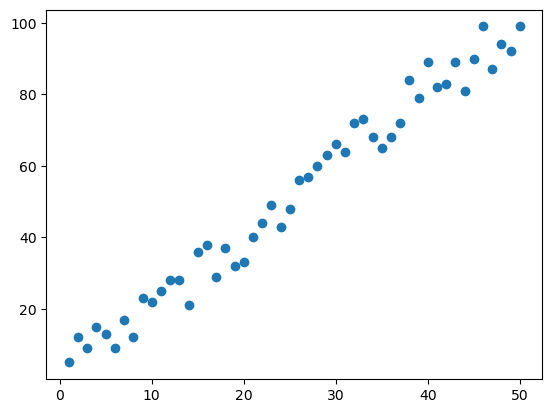

In [23]:
plt.scatter(X.numpy(), y.numpy());

We want to use PyTorch and fit a simple linear regression here.

When we set up X, we did not mention "grad_fn". Thus, it does not track opearions and it does not know the relationship between X and y.

First we want to see weights and bias. We only have one input and one output.

In [24]:
torch.manual_seed(59)

model = nn.Linear(in_features=1, out_features=1)

### Initial random weight and random bias:
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [25]:
### Now we set up the model class:

class Model(nn.Module):

    def __init__(self, in_features, out_features):

        super().__init__()
        self.linear = nn.Linear(in_features, out_features) 

    def forward(self,x):
        y_pred = self.linear(x)
        return y_pred

This defines a simple **linear regression model** in PyTorch:

- **`class Model(nn.Module)`** — inherits from PyTorch's base `nn.Module` class, which is the foundation for all neural network models.
- **`__init__`** — the constructor takes `in_features` and `out_features` as arguments and creates a single linear layer (`nn.Linear`), which applies the transformation **y = xW + b**.
- **`forward`** — defines the forward pass. When you call the model with input `x`, it passes the data through the linear layer and returns a prediction `y_pred`.

In short, this is a minimal single-layer neural network suited for tasks like linear regression.

Moreover, the linear model layer (nn.Linear) does not refer to linear regression. It defines a type of neural network layer employed here. A linear layer is a dense / fully connected layer, and moving forward, we would have a linear layer/convolution layer/pooling layer, and so on.


In [26]:
torch.manual_seed(59)

model = Model(1,1)

### Initial layer random weight and bias:
print(model.linear.weight)
print(model.linear.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [27]:
for name,param in model.named_parameters():
    print(name,'\t',param.item())

linear.weight 	 0.10597813129425049
linear.bias 	 0.9637961387634277


In [28]:
x = torch.tensor([2.0])
print(model.forward(x))

tensor([1.1758], grad_fn=<ViewBackward0>)


In [29]:
### See how the model predicts y values for different values of x.
### Note: We did not train the model. We are starting with a random weight and bias, and we expect the model to perform not that well.

x1 = np.linspace(0.0,50.0,50)
x1

array([ 0.        ,  1.02040816,  2.04081633,  3.06122449,  4.08163265,
        5.10204082,  6.12244898,  7.14285714,  8.16326531,  9.18367347,
       10.20408163, 11.2244898 , 12.24489796, 13.26530612, 14.28571429,
       15.30612245, 16.32653061, 17.34693878, 18.36734694, 19.3877551 ,
       20.40816327, 21.42857143, 22.44897959, 23.46938776, 24.48979592,
       25.51020408, 26.53061224, 27.55102041, 28.57142857, 29.59183673,
       30.6122449 , 31.63265306, 32.65306122, 33.67346939, 34.69387755,
       35.71428571, 36.73469388, 37.75510204, 38.7755102 , 39.79591837,
       40.81632653, 41.83673469, 42.85714286, 43.87755102, 44.89795918,
       45.91836735, 46.93877551, 47.95918367, 48.97959184, 50.        ])

In [30]:
w1 = 0.1059
b1 = 0.9637

print(w1, b1)

0.1059 0.9637


In [31]:
y1 = w1*x1 + b1
y1

array([0.9637    , 1.07176122, 1.17982245, 1.28788367, 1.3959449 ,
       1.50400612, 1.61206735, 1.72012857, 1.8281898 , 1.93625102,
       2.04431224, 2.15237347, 2.26043469, 2.36849592, 2.47655714,
       2.58461837, 2.69267959, 2.80074082, 2.90880204, 3.01686327,
       3.12492449, 3.23298571, 3.34104694, 3.44910816, 3.55716939,
       3.66523061, 3.77329184, 3.88135306, 3.98941429, 4.09747551,
       4.20553673, 4.31359796, 4.42165918, 4.52972041, 4.63778163,
       4.74584286, 4.85390408, 4.96196531, 5.07002653, 5.17808776,
       5.28614898, 5.3942102 , 5.50227143, 5.61033265, 5.71839388,
       5.8264551 , 5.93451633, 6.04257755, 6.15063878, 6.2587    ])

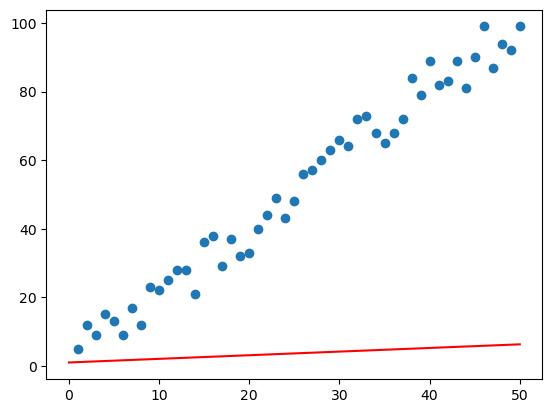

In [32]:
plt.scatter(X.numpy(), y.numpy()) ### Acutal values
plt.plot(x1,y1,'r'); ### Predictions

In [33]:
### Define a loss function (people usually call it a criterion) for us.

criterion = nn.MSELoss()

In [34]:
### Setup an optimization. Here we use stochastic gradient descent (SGD) with a given learning rate.
### We may have to try a couple of learning rates to pick the best one for us.

optimizer = torch.optim.SGD(model.parameters(),lr=0.001)

In [35]:
### Train the model. For that, we need epochs (how many passes through the entire data).

epochs = 50
losses = [] ### Placeholder for loss function value/error

for i in range(epochs):

    i = i+1

    ### Predicting on the forward pass
    y_pred = model.forward(X)

    ### Calculate our loss (error)
    loss = criterion(y_pred,y)

    ### Record the error
    losses.append(loss)

    print(f"epoch {i} loss: {loss.item()} weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}")

    ### Reset the optimizer for each iteration.
    optimizer.zero_grad()

    ### Backpropagation (backpropagate loss function)
    loss.backward()
    
    optimizer.step()

epoch 1 loss: 3057.216796875 weight: 0.10597813129425049 bias: 0.9637961387634277
epoch 2 loss: 1588.5311279296875 weight: 3.334900379180908 bias: 1.0604636669158936
epoch 3 loss: 830.2999877929688 weight: 1.0148327350616455 bias: 0.9922628402709961
epoch 4 loss: 438.8524169921875 weight: 2.6817996501922607 bias: 1.0425218343734741
epoch 5 loss: 236.7615203857422 weight: 1.4840211868286133 bias: 1.0076650381088257
epoch 6 loss: 132.4291229248047 weight: 2.3446059226989746 bias: 1.0339646339416504
epoch 7 loss: 78.56572723388672 weight: 1.7262253761291504 bias: 1.0163217782974243
epoch 8 loss: 50.75775909423828 weight: 2.170504093170166 bias: 1.0302516222000122
epoch 9 loss: 36.4012336730957 weight: 1.8512457609176636 bias: 1.0214954614639282
epoch 10 loss: 28.989229202270508 weight: 2.0806007385253906 bias: 1.029038906097412
epoch 11 loss: 25.162382125854492 weight: 1.9157683849334717 bias: 1.0248701572418213
epoch 12 loss: 23.186473846435547 weight: 2.034165620803833 bias: 1.029116272

After a certain number of epochs, we observe no significant improvements.

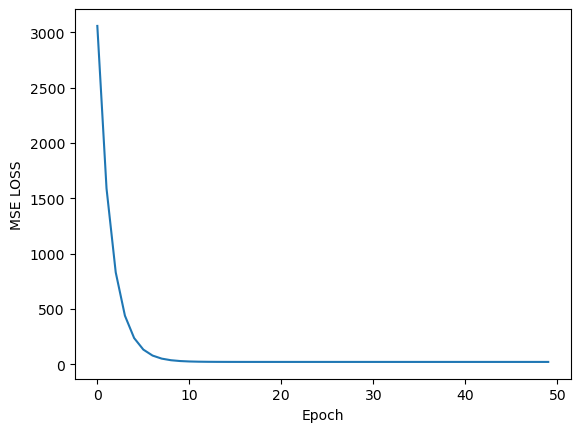

In [36]:
plt.plot(range(epochs), [loss.item() for loss in losses])
plt.ylabel('MSE LOSS')
plt.xlabel('Epoch');

In [37]:
### Final model predictions (we use weights and bias from the last fitted model)

x = np.linspace(0.0,50.0,50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight*x + current_bias
predicted_y

array([  1.05575156,   3.08005679,   5.10436203,   7.12866726,
         9.15297249,  11.17727772,  13.20158295,  15.22588818,
        17.25019342,  19.27449865,  21.29880388,  23.32310911,
        25.34741434,  27.37171957,  29.39602481,  31.42033004,
        33.44463527,  35.4689405 ,  37.49324573,  39.51755096,
        41.5418562 ,  43.56616143,  45.59046666,  47.61477189,
        49.63907712,  51.66338236,  53.68768759,  55.71199282,
        57.73629805,  59.76060328,  61.78490851,  63.80921375,
        65.83351898,  67.85782421,  69.88212944,  71.90643467,
        73.9307399 ,  75.95504514,  77.97935037,  80.0036556 ,
        82.02796083,  84.05226606,  86.07657129,  88.10087653,
        90.12518176,  92.14948699,  94.17379222,  96.19809745,
        98.22240268, 100.24670792])

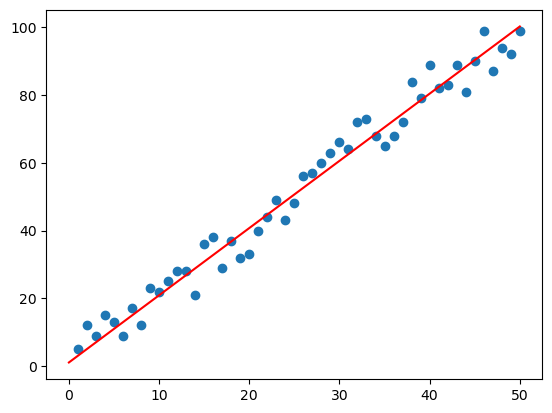

In [38]:
### Plot the results

plt.scatter(X.numpy(), y.numpy())
plt.plot(x, predicted_y,'r');

### Predictions seem to be accurate.

#### DataSets with PyTorch

In this section we investigate how to read data with PyTorch (PyTorch data utility function). Then, check built-in datasests using torch vision library.

**Method 1:** (Classical approach)

In [39]:
import pandas as pd

In [40]:
df = pd.read_csv("Chapter5_iris.csv")
df.head()

### Note: There are 3 kinds (classes): Target = 0,1,2

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


Link: https://en.wikipedia.org/wiki/Iris_flower_data_set

In [41]:
df.shape

(150, 5)

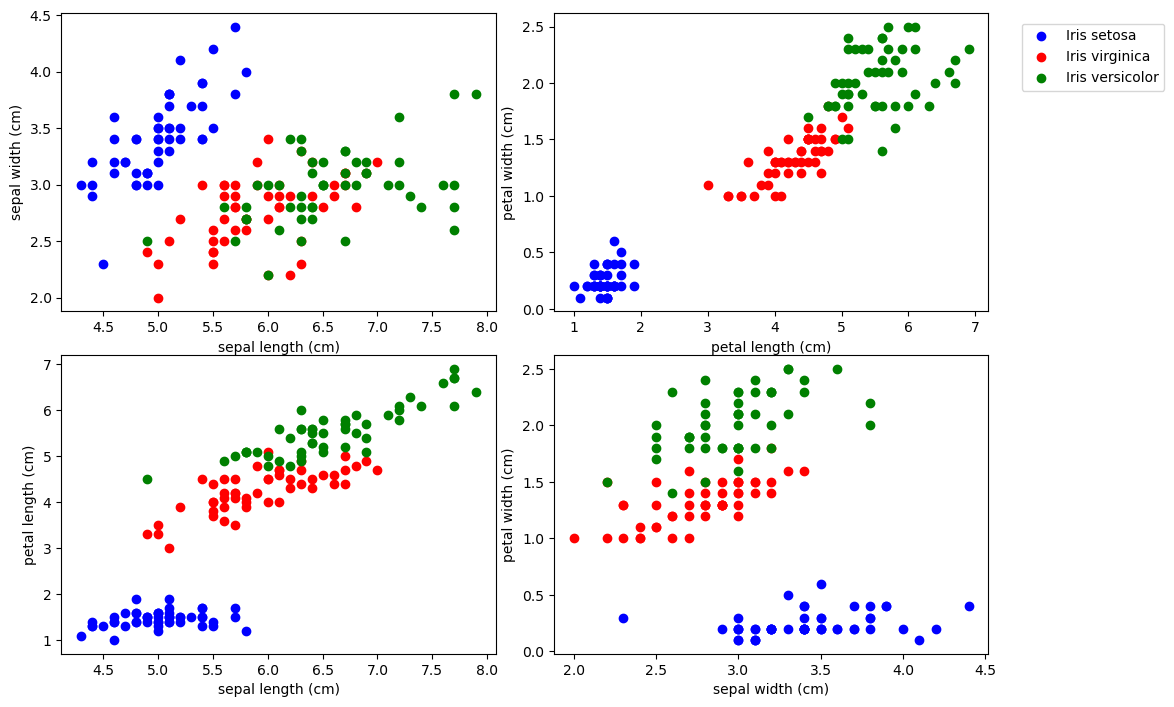

In [42]:
### Plot the data

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
fig.tight_layout()

plots = [(0,1),(2,3),(0,2),(1,3)]
colors = ['b', 'r', 'g']
labels = ['Iris setosa','Iris virginica','Iris versicolor']

for i, ax in enumerate(axes.flat):
    for j in range(3):
        x = df.columns[plots[i][0]]
        y = df.columns[plots[i][1]]
        ax.scatter(df[df['target']==j][x], df[df['target']==j][y], color=colors[j])
        ax.set(xlabel=x, ylabel=y)

fig.legend(labels=labels, loc=3, bbox_to_anchor=(1.0,0.85))
plt.show()

In [43]:
### We can create training and testing data using sklearn:

from sklearn.model_selection import train_test_split

In [44]:
features = df.drop('target',axis=1).values
label = df['target'].values

In [45]:
X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.20, random_state=33)

In [46]:
### Now we need to convert them to tensors

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train).reshape(-1,1) ### currently y_train and y_test are just row vectors.
y_test = torch.LongTensor(y_test).reshape(-1,1)

**Method 2:** (Use PyTorch built-in utilities)

In [47]:
from torch.utils.data import TensorDataset, DataLoader

In [48]:
data = df.drop('target', axis=1).values
labels = df['target'].values

In [49]:
iris = TensorDataset(torch.FloatTensor(data), torch.LongTensor(labels))

In [50]:
type(iris)

torch.utils.data.dataset.TensorDataset

Note now iris is now PyTorch TensorDataset object.

In [51]:
len(iris)

150

We can read through the data as follows:

for i in iris:
    print(i)

This is important and convenient. Now we can create random batches of data and feed them into the models. This is specifically needed when working with neural networks.

In [52]:
iris_loader = DataLoader(iris, batch_size=50, shuffle=True)

Now we can view the DataLoader object as follows:

for i_batch, sample_batch in enumerate(iris_loader):
    print(i_batch, sample_batch)

#### Basic PyTorch ANN

Here, we check the general process of creating an Artificial Neural Network to create a predictive algorithm.

Example: Use Sepal and Petal lengths and widths to predict flower species.

Here, we will be using Object Oriented Programming (OOP) with Python for this.

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [54]:
### Create a model class:

class Model(nn.Module):

    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        ### How many layers?
        ### Input layer (4 features for iris data) --> h1 (N neurons) --> h2 (N neurons) --> Output (3 classes)

        super().__init__() ### Initiate based on the nn.Module
        self.fc1 = nn.Linear(in_features, h1) ### fc == fully connected
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features) ### Last layer

    def forward(self, x): ### Define propogation method
        
        x = F.relu(self.fc1(x)) ### Define activation function in each layer
        x = F.relu(self.fc2(x))
        x = self.out(x)

        ### Note: IF need, instead of x we can use a1, a2 and so on.

        return x
        

In [55]:
### Create an instance of the model class

torch.manual_seed(32)

model = Model()

In [56]:
### Import the data

df = pd.read_csv('Chapter5_iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [57]:
df.tail()

### Note: Data set is sorted based on the response of "target"

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


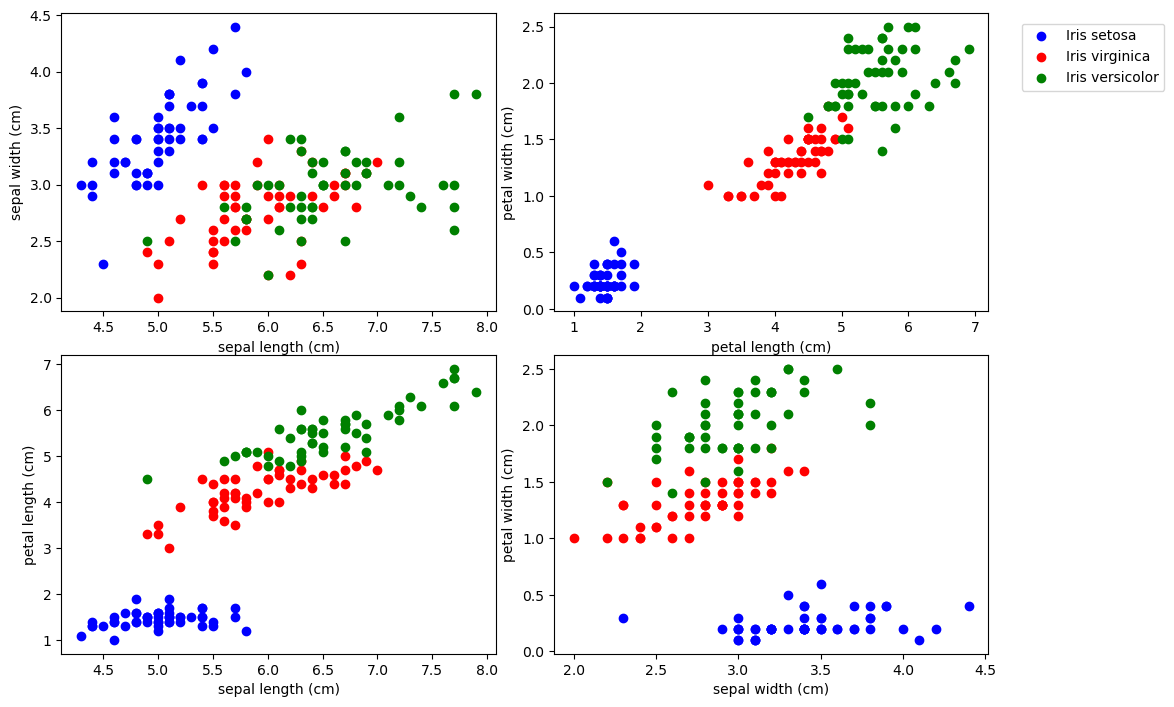

In [58]:
### Plot the data

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
fig.tight_layout()

plots = [(0,1),(2,3),(0,2),(1,3)]
colors = ['b', 'r', 'g']
labels = ['Iris setosa','Iris virginica','Iris versicolor']

for i, ax in enumerate(axes.flat):
    for j in range(3):
        x = df.columns[plots[i][0]]
        y = df.columns[plots[i][1]]
        ax.scatter(df[df['target']==j][x], df[df['target']==j][y], color=colors[j])
        ax.set(xlabel=x, ylabel=y)

fig.legend(labels=labels, loc=3, bbox_to_anchor=(1.0,0.85))
plt.show()

In [59]:
X = df.drop('target', axis = 1)
y = df['target']

In [60]:
type(y)

pandas.core.series.Series

In [61]:
### Convert to numpy arrays (for plotting)

X = X.values
y = y.values

In [62]:
type(y)

numpy.ndarray

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=33)

In [65]:
### Convert these to float tensors

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [66]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [67]:
criterion = nn.CrossEntropyLoss() ### Becase this is miulti-class classification problem

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [68]:
model.parameters()

### This is a generator object returning model parameters.

<generator object Module.parameters at 0x000002A3C8571350>

In [69]:
model.parameters

### Layers of the model

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

The next step is to train the model. Before train the model, we need to decide several things.

- The number of epochs (Hint: Start small and later it can be increased. May be 1 run through all the training data)


In [70]:
epochs = 100
losses = []

for i in range(epochs):

    ### Run model forward and get predictions
    y_pred = model.forward(X_train)

    ### Calculate loss/error
    loss = criterion(y_pred, y_train)

    losses.append(loss)

    if i%10==0:
        print(f'Epoch {i} and loss is: {loss}')

    ### Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

Epoch 0 and loss is: 1.1507114171981812
Epoch 10 and loss is: 0.9377314448356628
Epoch 20 and loss is: 0.779825747013092
Epoch 30 and loss is: 0.6099399924278259
Epoch 40 and loss is: 0.40079933404922485
Epoch 50 and loss is: 0.25436317920684814
Epoch 60 and loss is: 0.15053051710128784
Epoch 70 and loss is: 0.10086944699287415
Epoch 80 and loss is: 0.08128312975168228
Epoch 90 and loss is: 0.07231426984071732


In [71]:
type(loss.item() for loss in losses)

generator

In [72]:
### Just printing first 10 values:

[loss.item() for loss in losses][1:10]

[1.1166610717773438,
 1.0874042510986328,
 1.0641883611679077,
 1.0432250499725342,
 1.0236355066299438,
 1.0051639080047607,
 0.9889662861824036,
 0.9738515615463257,
 0.9566181898117065]

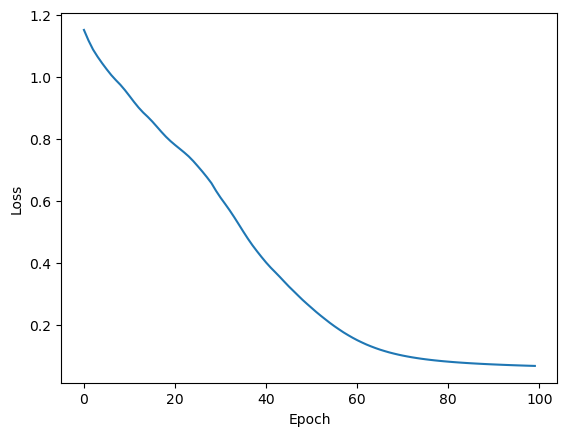

In [73]:
### Is the 100 epochs sufficient? The best way to test this is by plotting the losses.

plt.plot(range(epochs), [loss.item() for loss in losses])
plt.ylabel('Loss')
plt.xlabel('Epoch');

The next step is to validate the model with testing data.

In [74]:
with torch.no_grad(): ### Basically, telling torch we no longer backpropagate (reduce memory usage and speed up computations)
    y_eval = model.forward(X_test)
    loss = criterion(y_eval,y_test)

In [75]:
loss

### The loss is in the range of the training data. Indicating we are not overfitting.

tensor(0.0581)

In [76]:
### Now let's see how many cases we predicted correctly.

correct = 0

with torch.no_grad():

    for i, data in enumerate(X_test):

        y_val = model.forward(data)

        print(f'{i+1} {str(y_val)} {y_test[i]}')

### The highest value indicates the likelihood of the class it thinks that particular instance belongs to.

1 tensor([-2.1252,  4.8064, -0.8628]) 1
2 tensor([-1.7985,  5.3098, -1.5449]) 1
3 tensor([  6.3542,   0.8438, -10.0541]) 0
4 tensor([-3.9123,  4.5958,  1.1693]) 1
5 tensor([-7.4713,  3.2021,  5.7853]) 2
6 tensor([-10.4976,   1.6459,   9.6297]) 2
7 tensor([  6.3201,   0.9917, -10.1532]) 0
8 tensor([  7.0468,   0.7059, -10.9137]) 0
9 tensor([-7.2061,  3.3477,  5.3565]) 2
10 tensor([-9.3960,  2.5759,  8.1033]) 2
11 tensor([-9.8808,  2.3475,  8.7141]) 2
12 tensor([ 6.2748,  0.6655, -9.7613]) 0
13 tensor([-9.3142,  2.1880,  8.1947]) 2
14 tensor([-3.7803,  4.5050,  1.0752]) 1
15 tensor([-7.8657,  3.0117,  6.2303]) 2
16 tensor([-1.8867,  5.1572, -1.3345]) 1
17 tensor([-5.7006,  3.5030,  3.6696]) 2
18 tensor([  7.1789,   0.7369, -11.1350]) 0
19 tensor([-3.2944,  4.7931,  0.3475]) 1
20 tensor([-7.7665,  3.7629,  5.7095]) 2
21 tensor([  6.6499,   0.7889, -10.4252]) 0
22 tensor([  7.4357,   0.8918, -11.6600]) 0
23 tensor([-9.7584,  2.1744,  8.6654]) 2
24 tensor([  6.5770,   0.7421, -10.2733]) 0
2

In [77]:
correct = 0

with torch.no_grad():

    for i, data in enumerate(X_test):

        y_val = model.forward(data)

        print(f'{i+1} {str(y_val)} {y_test[i]}')

        if y_val.argmax().item() == y_test[i]:
            correct += 1
            
print(f'We got {correct} correct!')

1 tensor([-2.1252,  4.8064, -0.8628]) 1
2 tensor([-1.7985,  5.3098, -1.5449]) 1
3 tensor([  6.3542,   0.8438, -10.0541]) 0
4 tensor([-3.9123,  4.5958,  1.1693]) 1
5 tensor([-7.4713,  3.2021,  5.7853]) 2
6 tensor([-10.4976,   1.6459,   9.6297]) 2
7 tensor([  6.3201,   0.9917, -10.1532]) 0
8 tensor([  7.0468,   0.7059, -10.9137]) 0
9 tensor([-7.2061,  3.3477,  5.3565]) 2
10 tensor([-9.3960,  2.5759,  8.1033]) 2
11 tensor([-9.8808,  2.3475,  8.7141]) 2
12 tensor([ 6.2748,  0.6655, -9.7613]) 0
13 tensor([-9.3142,  2.1880,  8.1947]) 2
14 tensor([-3.7803,  4.5050,  1.0752]) 1
15 tensor([-7.8657,  3.0117,  6.2303]) 2
16 tensor([-1.8867,  5.1572, -1.3345]) 1
17 tensor([-5.7006,  3.5030,  3.6696]) 2
18 tensor([  7.1789,   0.7369, -11.1350]) 0
19 tensor([-3.2944,  4.7931,  0.3475]) 1
20 tensor([-7.7665,  3.7629,  5.7095]) 2
21 tensor([  6.6499,   0.7889, -10.4252]) 0
22 tensor([  7.4357,   0.8918, -11.6600]) 0
23 tensor([-9.7584,  2.1744,  8.6654]) 2
24 tensor([  6.5770,   0.7421, -10.2733]) 0
2

In [78]:
### Directly compare predictions and true values:

with torch.no_grad():

    for i, data in enumerate(X_test):

        y_val = model.forward(data)

        print(f'{i+1} {str(y_val.argmax().item())} {y_test[i]}')

1 1 1
2 1 1
3 0 0
4 1 1
5 2 2
6 2 2
7 0 0
8 0 0
9 2 2
10 2 2
11 2 2
12 0 0
13 2 2
14 1 1
15 2 2
16 1 1
17 2 2
18 0 0
19 1 1
20 2 2
21 0 0
22 0 0
23 2 2
24 0 0
25 2 2
26 2 2
27 1 1
28 1 1
29 2 2
30 2 2


In [79]:
### Save the model:

torch.save(model.state_dict(), 'my_iris_model.pt')

In [80]:
### Let's create a new model. This model does not know what the best weights and biases are.

new_model = Model()

In [81]:
### We can use the trained and saved model to get weights

new_model.load_state_dict(torch.load('my_iris_model.pt'))

new_model.eval()

C:\Users\sulal\AppData\Local\Temp\ipykernel_13768\3994121909.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load('my_iris_model.pt'))


Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

In [82]:
### Use this model on completely unseen data (for a new single flower)

mystery_iris = torch.tensor([5.6,3.7,2.2,0.5])

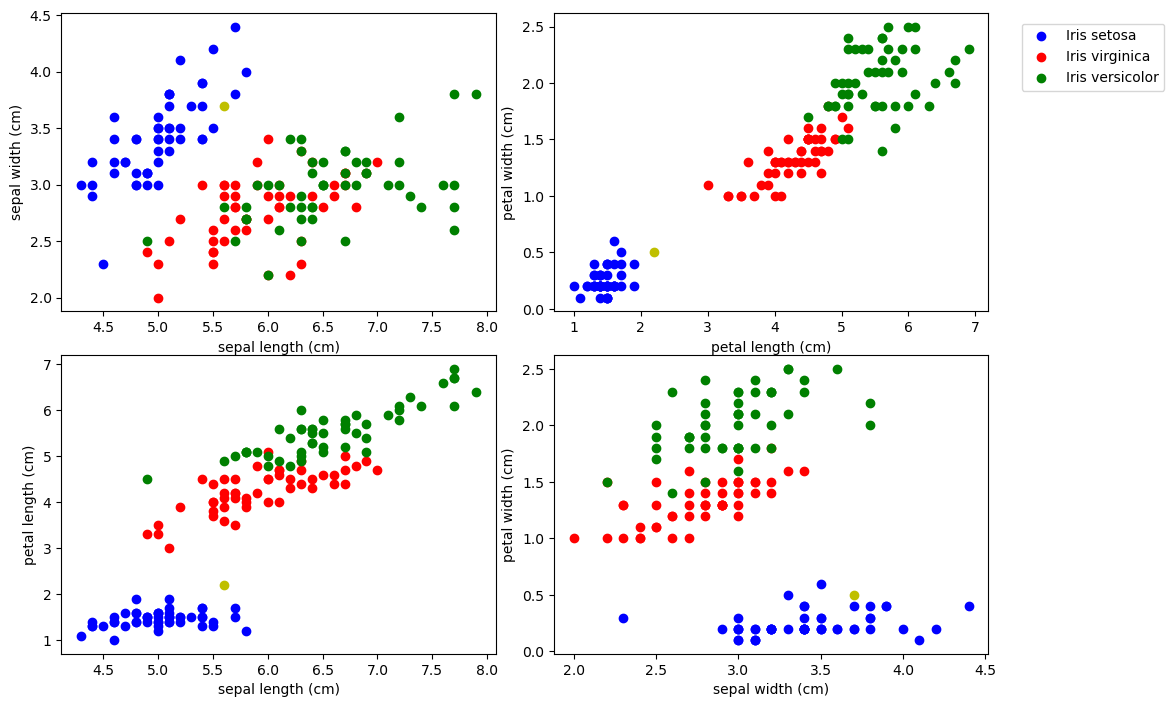

In [83]:
### We can plot this new flower in the plot to see which class it would belong to
### Color of the new point is yellow. Probably it belongs to "Iris setosa".

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,7))
fig.tight_layout()

plots = [(0,1),(2,3),(0,2),(1,3)]
colors = ['b', 'r', 'g']
labels = ['Iris setosa','Iris virginica','Iris versicolor']

for i, ax in enumerate(axes.flat):
    for j in range(3):
        x = df.columns[plots[i][0]]
        y = df.columns[plots[i][1]]
        ax.scatter(df[df['target']==j][x], df[df['target']==j][y], color=colors[j])
        ax.set(xlabel=x, ylabel=y)

    # Add a plot for our mystery iris:
    ax.scatter(mystery_iris[plots[i][0]],mystery_iris[plots[i][1]], color='y')

fig.legend(labels=labels, loc=3, bbox_to_anchor=(1.0,0.85))
plt.show()

In [84]:
with torch.no_grad():
    print(new_model(mystery_iris))
    print(new_model(mystery_iris).argmax().item())

### Thus, it belongs to class 0. In other words, to "Iris setosa"

tensor([  5.9522,   1.5596, -10.0054])
0


#### Full ANN Regression Along

The `iris` dataset is very convenient. Features are continuous, only 4 columns, 3 categories/classes, no need for feature engineering, and the range for the features is in the same range (no need for any normalization).

Now we are going look at a more realistic data set and apply an ANN for regression and classification tasks.

**Data**: From Kaggle (original 55 million records). Here we use 120,000 records. Link: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction

It contains taxi data: pickup date and time, latitude and longitude (GPS coordinates) of the pickup and dropoff locations, and number of passengers.

**Goal**: Give the above information, how much should the taxi charge?

What matters?

- Time of the day?
- Time of the week?
- How do we measure distance?

Note that ANN can only take in numerical data (probably won't understand direct complex data such as datetime, latitude, ...)

Project Steps:

- Read data
- Feature Engineering (calculate distance, derive useful data, and time statistics).
- Deal with categorical data (embedding)
- use TabularModel class (continuous/categorical)
- Add loss function and optimizer
- Train/Test split
- Train the model
- Evaluate on test data
- Predict on new data


**Feature Engineering**

In [85]:
### Import Data:

df = pd.read_csv('Chapter5_NYCTaxiFares.csv')
df.head()

### Note: "fare_class" is used when the dataset is studied as a classification problem

,pickup_datetime,fare_amount,fare_class,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2010-04-19 08:17:56 UTC,6.5,0,-73.992365,40.730521,-73.975499,40.744746,1
1,2010-04-17 15:43:53 UTC,6.9,0,-73.990078,40.740558,-73.974232,40.744114,1
2,2010-04-17 11:23:26 UTC,10.1,1,-73.994149,40.751118,-73.960064,40.766235,2
3,2010-04-11 21:25:03 UTC,8.9,0,-73.990485,40.756422,-73.971205,40.748192,1
4,2010-04-17 02:19:01 UTC,19.7,1,-73.990976,40.734202,-73.905956,40.743115,1


In [87]:
df['fare_amount'].describe()

count    120000.000000
mean         10.040326
std           7.500134
min           2.500000
25%           5.700000
50%           7.700000
75%          11.300000
max          49.900000
Name: fare_amount, dtype: float64

**Note**: We would not be able to use longitude and latitude directly, as in a smaller area like New York City, these values are very close (expect changes in the 3rd or 4th decimal place).

Thus, we will focus on the distance between the pickup point and the drop-off point. We can use the **Haversine formula**.

The distance formula works out to

${\displaystyle d=2r\arcsin \left({\sqrt {\sin ^{2}\left({\frac {\varphi _{2}-\varphi _{1}}{2}}\right)+\cos(\varphi _{1})\:\cos(\varphi _{2})\:\sin ^{2}\left({\frac {\lambda _{2}-\lambda _{1}}{2}}\right)}}\right)}$

where

$\begin{split} r&: \textrm {radius of the sphere (Earth's radius averages 6371 km)}\\
\varphi_1, \varphi_2&: \textrm {latitudes of point 1 and point 2}\\
\lambda_1, \lambda_2&: \textrm {longitudes of point 1 and point 2}\end{split}$

In [88]:
def haversine_distance(df, lat1, long1, lat2, long2):
    """
    Calculates the haversine distance between 2 sets of GPS coordinates in df
    """
    r = 6371  # average radius of Earth in kilometers
       
    phi1 = np.radians(df[lat1])
    phi2 = np.radians(df[lat2])
    
    delta_phi = np.radians(df[lat2]-df[lat1])
    delta_lambda = np.radians(df[long2]-df[long1])
     
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = (r * c) # in kilometers

    return d